In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize
from models import CRW
from tqdm import tqdm

In [2]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
figsize = (12,9)

In [3]:
# generate 1000 CRW polymers of length 10-1000, and record their statistics
low=10
high=1000

num_crw = 500

rng = np.random.default_rng()
crw_list = [CRW(int(10**rng.uniform(np.log10(low),np.log10(high)))) for i in tqdm(range(num_crw))]

100%|██████████| 500/500 [00:02<00:00, 208.12it/s]


In [4]:
print(crw_list)
crw_list = sorted(crw_list, key=lambda x: x.n)
print(crw_list)

[<models.CRW object at 0x75c495b972f0>, <models.CRW object at 0x75c4959093d0>, <models.CRW object at 0x75c495b43140>, <models.CRW object at 0x75c495f54c20>, <models.CRW object at 0x75c49597dbe0>, <models.CRW object at 0x75c49597dca0>, <models.CRW object at 0x75c49597de80>, <models.CRW object at 0x75c512bdb1a0>, <models.CRW object at 0x75c49594cc50>, <models.CRW object at 0x75c49594cbf0>, <models.CRW object at 0x75c49597dd30>, <models.CRW object at 0x75c49597c9e0>, <models.CRW object at 0x75c49597dac0>, <models.CRW object at 0x75c49597dd90>, <models.CRW object at 0x75c49597de20>, <models.CRW object at 0x75c49597deb0>, <models.CRW object at 0x75c49597dee0>, <models.CRW object at 0x75c49597ddf0>, <models.CRW object at 0x75c49597df10>, <models.CRW object at 0x75c49597df70>, <models.CRW object at 0x75c49597dfa0>, <models.CRW object at 0x75c49597df40>, <models.CRW object at 0x75c49597e000>, <models.CRW object at 0x75c49597e030>, <models.CRW object at 0x75c495f56120>, <models.CRW object at 0x

In [5]:
crw_list[0].show()
crw_list[1].show()

CRW of length 10:
	Sigma: 1
	U_bb: 1
	e_rep: 1
Stats:
	Radius of Gyration: 2.035031795501709
	Total Potential Energy: 1.7763568394002505e-14
Residues:
(0.0, 0.0, 0.0)
(-0.5244994163513184, 0.7180303335189819, 0.4575289785861969)
(-0.38679707050323486, 0.8000304102897644, 1.4446024894714355)
(-0.2606697380542755, 1.7103564739227295, 1.838808298110962)
(0.1961810439825058, 2.599245309829712, 1.8046925067901611)
(-0.5765568017959595, 2.8182640075683594, 2.400433301925659)
(-1.417434811592102, 2.7617897987365723, 2.9387035369873047)
(-1.689091682434082, 2.670203924179077, 3.8967299461364746)
(-2.413038730621338, 2.8170697689056396, 4.570770740509033)
(-2.7017180919647217, 1.8745969533920288, 4.402220726013184)
CRW of length 10:
	Sigma: 1
	U_bb: 1
	e_rep: 1
Stats:
	Radius of Gyration: 1.2794408798217773
	Total Potential Energy: 2.3092638912203256e-14
Residues:
(0.0, 0.0, 0.0)
(0.4401199221611023, -0.14704172313213348, -0.88581782579422)
(0.3774952292442322, 0.8342955112457275, -1.0676293373

In [6]:
def Rg_func(N, v):
    return N**v

In [7]:
lengths = [crw.n for crw in tqdm(crw_list)]
R_gs = [float(crw.compute_rg()) for crw in tqdm(crw_list)]
xdata = lengths
ydata = R_gs

Rg_N_popt, Rg_N_pcov = scipy.optimize.curve_fit(
    Rg_func,
    xdata,
    ydata,
    p0=[.3]
)

print(Rg_N_popt, Rg_N_pcov)

print(lengths)
print(R_gs)

100%|██████████| 500/500 [00:00<00:00, 51147.55it/s]

[0.42358024] [[3.528819e-06]]
[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 22, 22, 23, 23, 23, 24, 24, 24, 25, 25, 25, 25, 25, 26, 26, 27, 27, 27, 27, 27, 27, 27, 27, 28, 28, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 30, 31, 31, 32, 32, 32, 32, 33, 33, 33, 33, 34, 34, 35, 35, 35, 35, 36, 36, 37, 37, 37, 37, 38, 38, 38, 38, 38, 38, 38, 40, 40, 41, 41, 41, 41, 41, 41, 42, 42, 43, 44, 45, 46, 46, 46, 47, 47, 47, 47, 47, 48, 48, 49, 49, 50, 51, 51, 52, 52, 52, 53, 53, 54, 54, 54, 54, 54, 54, 55, 55, 55, 55, 55, 55, 55, 56, 57, 57, 58, 58, 59, 59, 60, 60, 60, 63, 64, 65, 66, 66, 67, 68, 71, 72, 72, 72, 73, 73, 73, 74, 75, 76, 76, 77, 77, 78, 79, 80, 80, 82, 84, 8

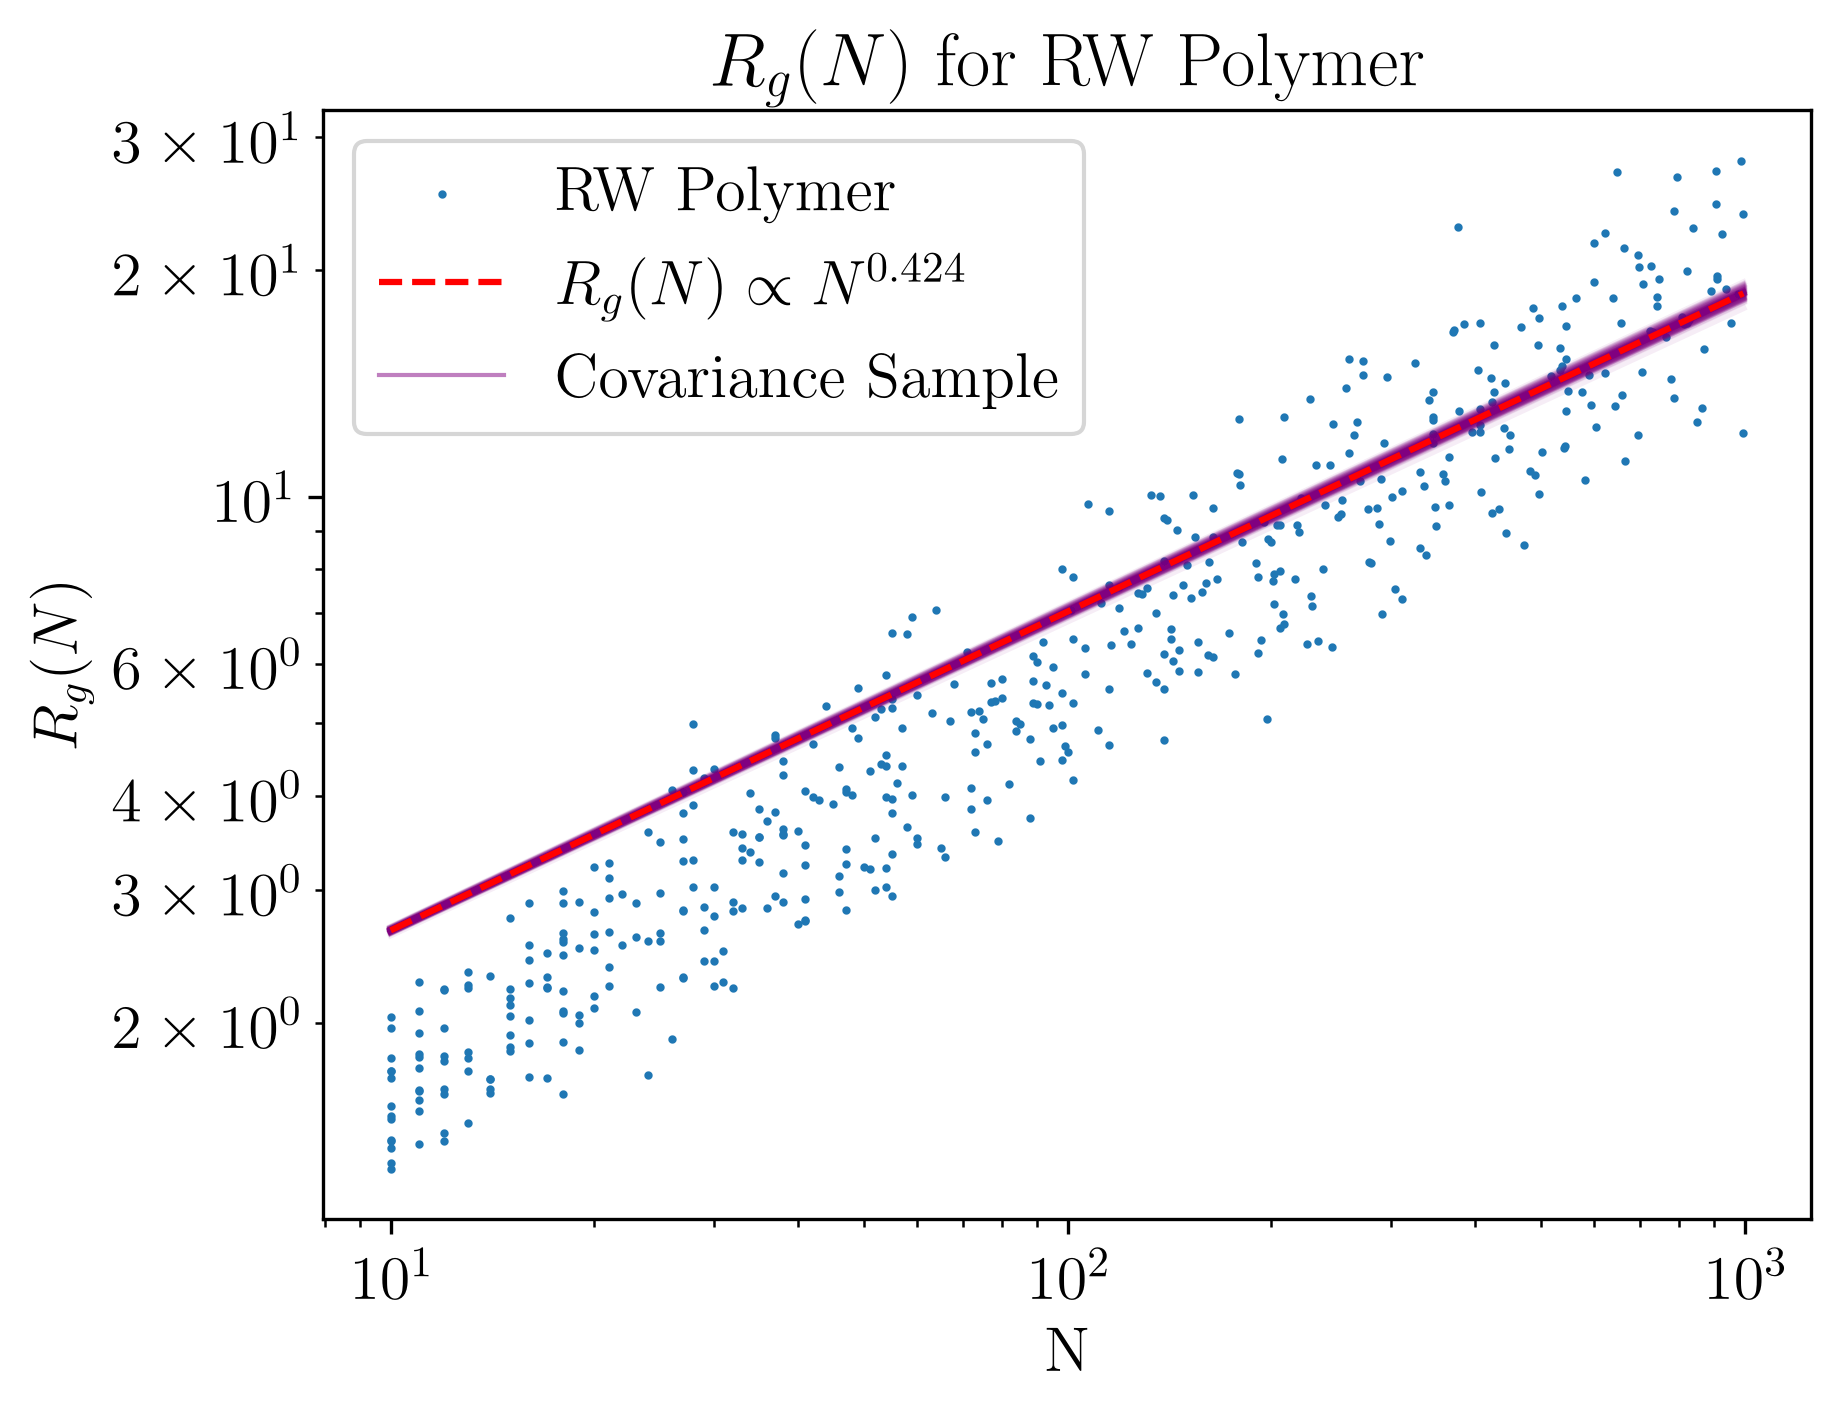

In [ ]:
plt.figure()
data = plt.scatter(lengths, R_gs, s=1, label="RW Polymer")

from matplotlib.lines import Line2D
sample_handle = Line2D(
    [],                  # no x-data
    [],                  # no y-data
    color="purple",
    alpha=0.5,
    linewidth=1,
    label="Covariance Sample",
)

for i in range(100):
    rand_fit = Rg_func(lengths, np.random.multivariate_normal(Rg_N_popt, Rg_N_pcov))
    plt.plot(lengths, rand_fit, color="purple",alpha=.07)
fit, = plt.plot(lengths, Rg_func(lengths, *Rg_N_popt),color="red",linestyle="--",linewidth=.5,label=rf"$R_g(N) \propto N^{{{Rg_N_popt[0]:.3f}}}$")
plt.ylabel(r"$R_g(N)$")
plt.xlabel("N")
plt.xscale("log")
plt.yscale("log")
plt.title(r"$R_g(N)$ for RW Polymer")
plt.legend(handles=[data, fit, sample_handle])
plt.savefig("RgVsN.png")

100%|██████████| 500/500 [02:38<00:00,  3.16it/s]  
/tmp/ipykernel_1189442/1102409254.py:26: RuntimeWarning: Mean of empty slice
  mean_Rg_n = np.nanmean(Rg_ns, axis=0)
/home/accts/ajy27/ohernlab/programs/constrained-polymer/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


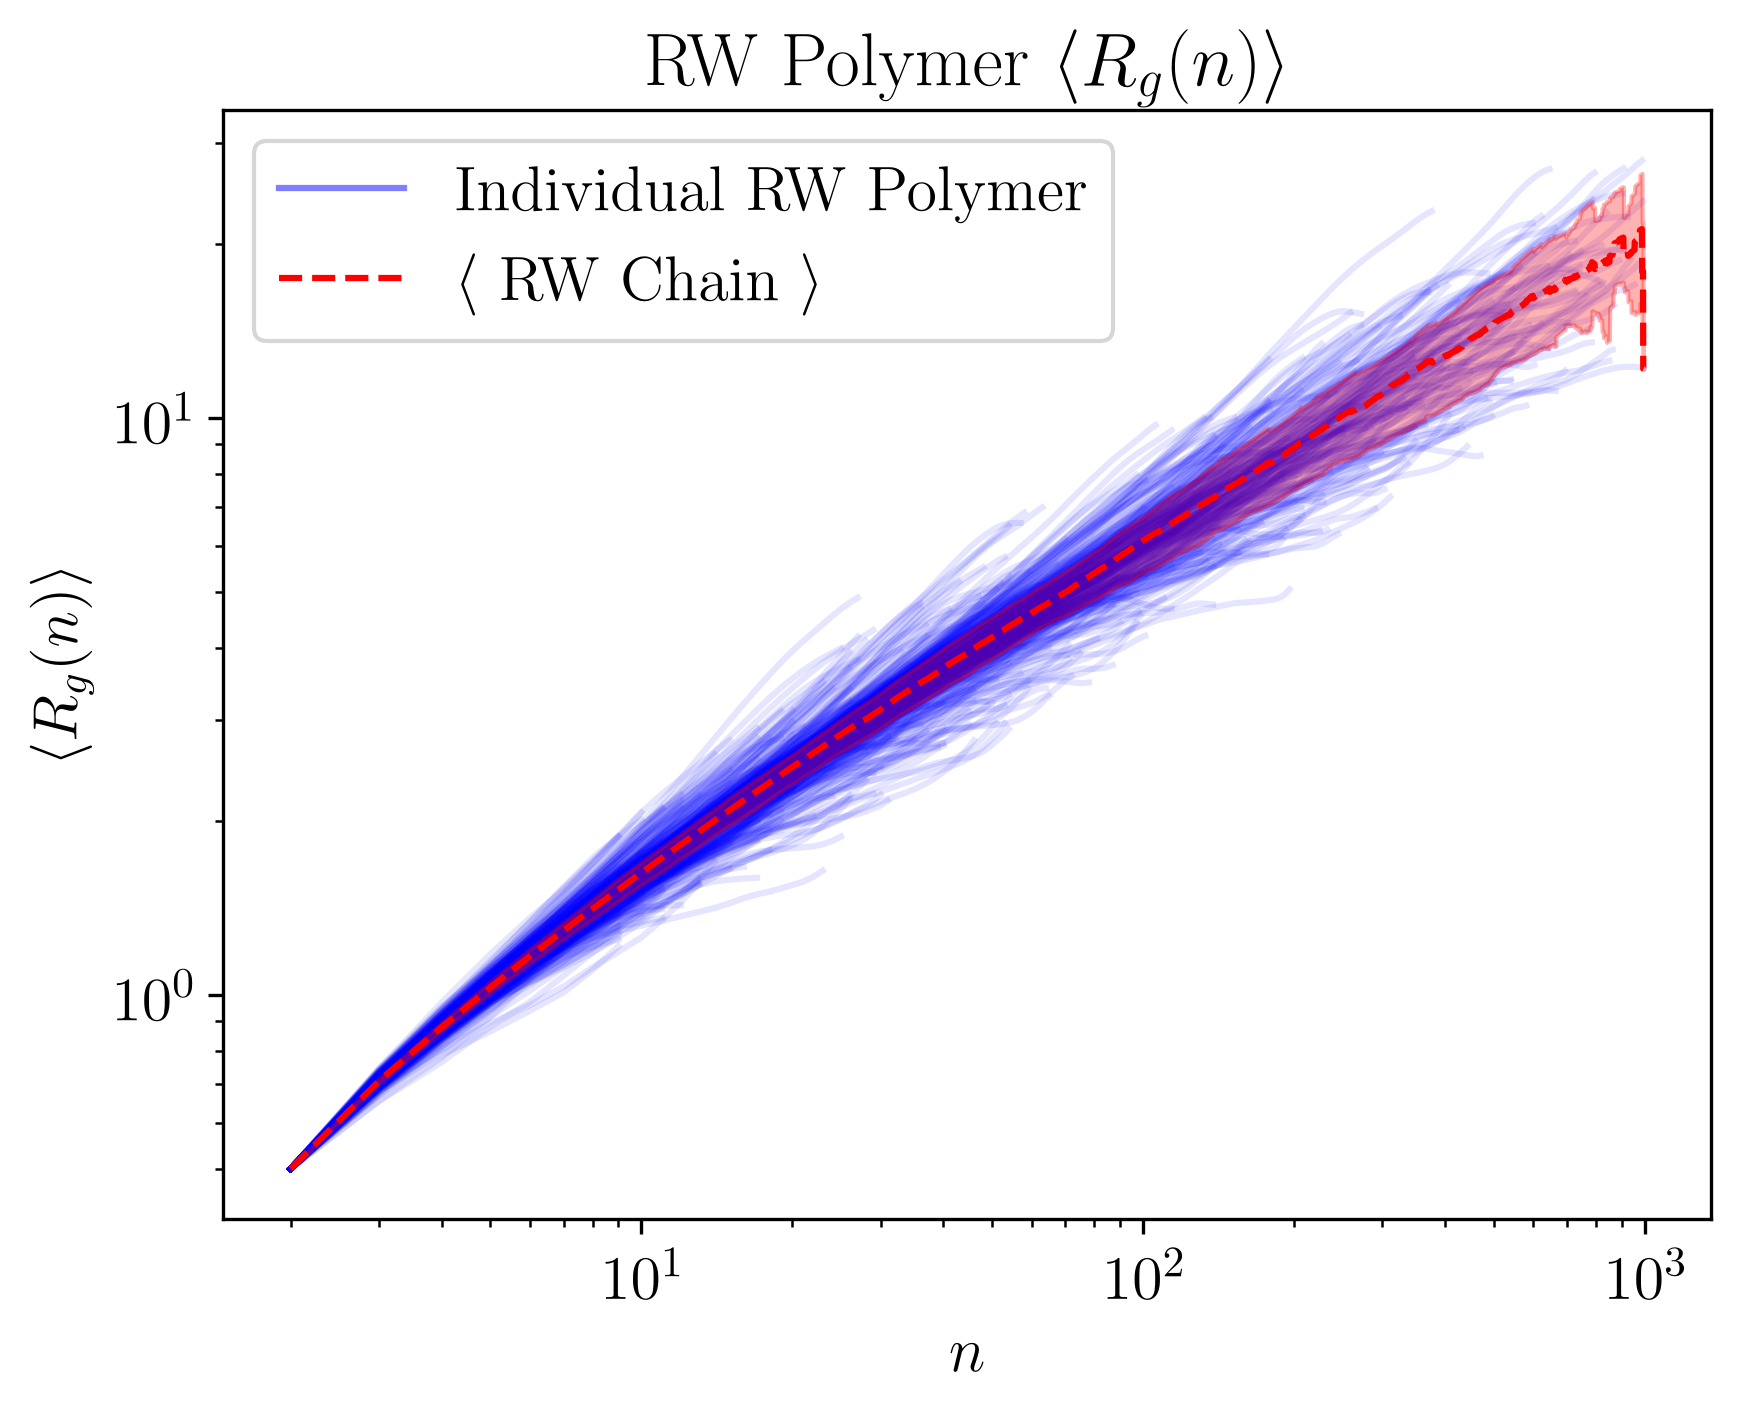

In [14]:
n_max = max(crw.n for crw in crw_list)

ns = np.arange(2, n_max+1)
Rg_ns = np.full((num_crw, len(ns)), np.nan)

plt.figure()
plt.title(r"RW Polymer $\langle R_g(n)\rangle$")
plt.xlabel(r"$n$")
plt.ylabel(r"$\langle R_g(n) \rangle$")
plt.xscale("log")
plt.yscale("log")
for crw_idx, crw in enumerate(tqdm(crw_list)):
    
    valid_ns = ns[ns < crw.n]
     
    for n_idx, n in enumerate(valid_ns):
        Rg_ns[crw_idx, n_idx]=crw.compute_rg_n(n)
    plt.plot(
             valid_ns, 
             Rg_ns[crw_idx, :len(valid_ns)], 
             c="b", 
             alpha=.1,
             zorder=1
        )

mean_Rg_n = np.nanmean(Rg_ns, axis=0)
Rg_lo, Rg_hi = np.nanpercentile(Rg_ns, [16, 84], axis=0)
sample_handle=Line2D(
    [],
    [],
    color="b",
    alpha=.5,
    label="Individual RW Polymer"
)
avg, = plt.plot(ns, mean_Rg_n, c="r", linestyle="--",label=r"$\langle$ RW Chain $\rangle$",zorder=3)
fill_between = plt.fill_between(ns, Rg_lo, Rg_hi, color="r", alpha=.3,zorder=2)
plt.legend(handles=[sample_handle, avg])
plt.savefig("Rg_n.png")
plt.show()

In [ ]:
# Now when the polymers begin to fold what happens?
# First examine different central forces, and what they do to to final R_g(N) and the <R_g(n)> at different temperatures
# first output files to respective configs

# for i, rw in enumerate(tqdm(crw_list)):
#     rw.write_sim_config(f"../../input/rw_len_{rw.n}_no_{i}.txt")

# create a job array from all parameters
# parameters to test
base_command = 